## Setup and Imports

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import os
import time

## Define Hyperparameters and Constants

In [ ]:
workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = '/media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/Datasets/CelebA'
IMAGE_SIZE = 64
CHANNELS = 3
BATCH_SIZE = 256

LATENT_DIM = 100
EPOCHS = 50
LEARNING_RATE = 0.0002
ADAM_BETA_1 = 0.5

Using device: cuda:0


## Load and Preprocess the Dataset

In [ ]:
dataset = dset.ImageFolder(root=DATA_DIR,
                           transform=transforms.Compose([
                               transforms.Resize(IMAGE_SIZE),
                               transforms.CenterCrop(IMAGE_SIZE),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))

dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE,
                                         shuffle=True, num_workers=workers)

## Build the Generator and Discriminator

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

netG = Generator().to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


## Define Loss Functions and Optimizers

In [ ]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

real_label = 1.
fake_label = 0.

optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(ADAM_BETA_1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(ADAM_BETA_1, 0.999))

## The Training Loop

In [ ]:
if not os.path.exists('gan_images_pytorch'):
    os.makedirs('gan_images_pytorch')

img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
for epoch in range(EPOCHS):
    start_time = time.time()
    for i, data in enumerate(dataloader, 0):
        
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()
        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        iters += 1
    
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake, padding=2, normalize=True))
    vutils.save_image(img_list[-1], f"gan_images_pytorch/epoch_{epoch+1}.png")
    
    print(f'Time for epoch {epoch+1} is {time.time()-start_time:.2f} sec | Loss_D: {errD.item():.4f} | Loss_G: {errG.item():.4f}')

Starting Training Loop...
Time for epoch 1 is 100.53 sec | Loss_D: 0.7191 | Loss_G: 3.5045
Time for epoch 2 is 104.34 sec | Loss_D: 0.5003 | Loss_G: 4.8183
Time for epoch 3 is 105.06 sec | Loss_D: 0.6673 | Loss_G: 3.3014
Time for epoch 4 is 105.13 sec | Loss_D: 0.4113 | Loss_G: 3.2810
Time for epoch 5 is 104.87 sec | Loss_D: 0.6385 | Loss_G: 2.3535
Time for epoch 6 is 105.25 sec | Loss_D: 0.7102 | Loss_G: 2.1090
Time for epoch 7 is 105.30 sec | Loss_D: 1.5049 | Loss_G: 5.6720
Time for epoch 8 is 105.01 sec | Loss_D: 1.3039 | Loss_G: 0.9275
Time for epoch 9 is 105.06 sec | Loss_D: 0.8958 | Loss_G: 3.2353
Time for epoch 10 is 105.45 sec | Loss_D: 0.5472 | Loss_G: 2.8579
Time for epoch 11 is 105.67 sec | Loss_D: 0.6576 | Loss_G: 2.4143
Time for epoch 12 is 105.01 sec | Loss_D: 0.6795 | Loss_G: 3.7218
Time for epoch 13 is 104.78 sec | Loss_D: 0.9496 | Loss_G: 1.0079
Time for epoch 14 is 105.41 sec | Loss_D: 0.6473 | Loss_G: 1.4190
Time for epoch 15 is 105.45 sec | Loss_D: 0.6491 | Loss_G: 

## Save Trained Models

In [ ]:
DCGAN_GENERATOR_PATH = 'dcgan_generator.pth'
DCGAN_DISCRIMINATOR_PATH = 'dcgan_discriminator.pth'
torch.save(netG.state_dict(), DCGAN_GENERATOR_PATH)
torch.save(netD.state_dict(), DCGAN_DISCRIMINATOR_PATH)
print(f"Task 1 models saved successfully!")
print(f"Generator weights saved to: {DCGAN_GENERATOR_PATH}")
print(f"Discriminator weights saved to: {DCGAN_DISCRIMINATOR_PATH}")

Task 1 models saved successfully!
Generator weights saved to: dcgan_generator.pth
Discriminator weights saved to: dcgan_discriminator.pth


## Visualization (Loss Plot & Side-by-Side Grid)

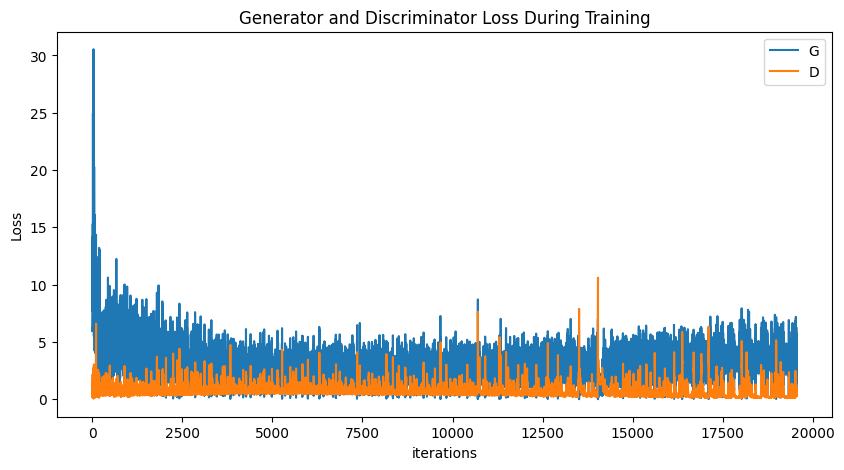

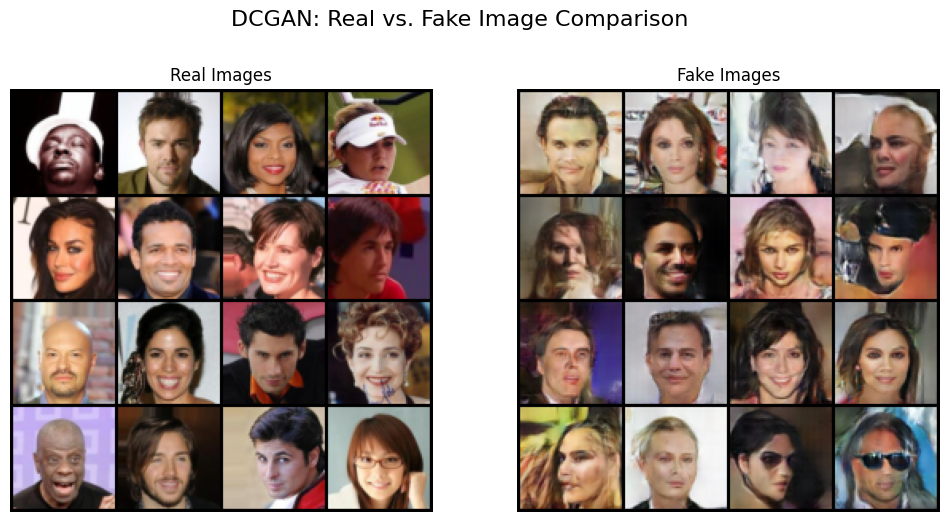

In [ ]:
if 'G_losses' in locals() and 'D_losses' in locals():
    plt.figure(figsize=(10,5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(G_losses,label="G")
    plt.plot(D_losses,label="D")
    plt.xlabel("iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Loss history not found in the current session. Skipping loss plot.")
real_batch = next(iter(dataloader))
with torch.no_grad():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)
    fake_images = netG(noise).detach().cpu()

plt.figure(figsize=(12, 6))
plt.suptitle("DCGAN: Real vs. Fake Image Comparison", fontsize=16)
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images")
real_grid = vutils.make_grid(real_batch[0][:16], nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(real_grid, (1, 2, 0)))
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images")
fake_grid = vutils.make_grid(fake_images, nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(fake_grid, (1, 2, 0)))

plt.show()

## Alternative Visualization (Top/Bottom Layout)

Loss history not found in the current session. Skipping loss plot.
Successfully loaded trained generator from 'dcgan_generator.pth'
Fetching 8 real images...
Generating 8 fake images...
Plotting results...


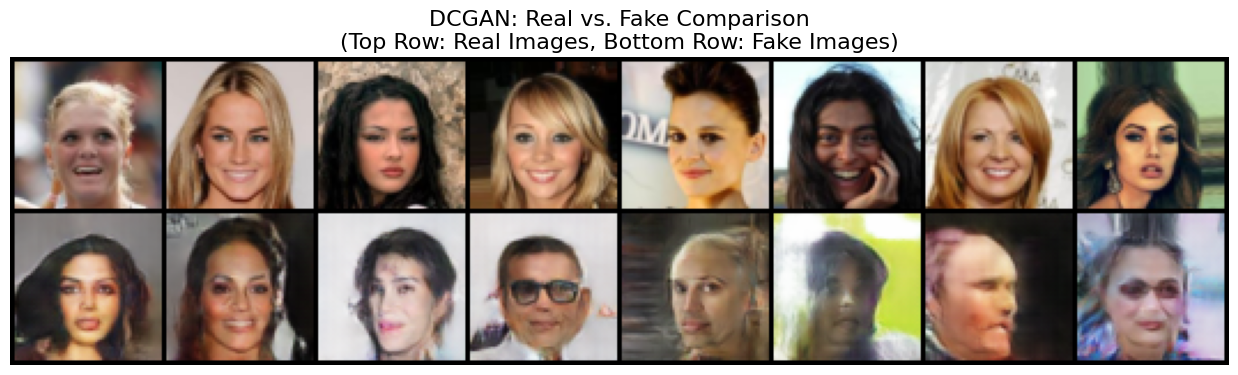

In [ ]:
if 'G_losses' in locals() and 'D_losses' in locals():
    plt.figure(figsize=(10,5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(G_losses,label="G")
    plt.plot(D_losses,label="D")
    plt.xlabel("iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Loss history not found in the current session. Skipping loss plot.")

GENERATOR_PATH = 'dcgan_generator.pth'
netG = Generator().to(device)

try:
    netG.load_state_dict(torch.load(GENERATOR_PATH))
    print(f"Successfully loaded trained generator from '{GENERATOR_PATH}'")
except FileNotFoundError:
    print(f"Error: Model file not found at '{GENERATOR_PATH}'.")
    print("Please make sure the training was completed and the file was saved.")

netG.eval()
print("Fetching 8 real images...")
real_batch = next(iter(dataloader))
real_images = real_batch[0][:8]

print("Generating 8 fake images...")
with torch.no_grad():
    noise = torch.randn(8, LATENT_DIM, 1, 1, device=device)
    fake_images = netG(noise).detach().cpu()

print("Plotting results...")

combined_images = torch.cat([real_images, fake_images], dim=0)
plt.figure(figsize=(16, 4))
plt.axis("off")
plt.title("DCGAN: Real vs. Fake Comparison\n(Top Row: Real Images, Bottom Row: Fake Images)", fontsize=16)
image_grid = vutils.make_grid(combined_images, nrow=8, padding=2, normalize=True)
plt.imshow(np.transpose(image_grid, (1, 2, 0)))

plt.show()

## Imports and Hyperparameters

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
workers = 4
DATA_DIR = '/media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/Datasets/celebA'
IMAGE_SIZE = 64
CHANNELS = 3
BATCH_SIZE = 256
LATENT_DIM = 100
EPOCHS = 50
LEARNING_RATE = 0.0002
ADAM_BETA_1 = 0.5
NUM_CLASSES = 2
LABEL_EMBEDDING_DIM = 50

Using device: cuda:0


## Custom Labeled Dataset

In [ ]:
class LongHairCelebADataset(Dataset):
    """
    Custom Dataset for CelebA.
    Defines 'long hair' (label 1) as having 'Blond_Hair' OR 'Wavy_Hair'.
    All other images are 'not long hair' (label 0).
    """
    def __init__(self, img_dir, attr_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        self.attr = pd.read_csv(attr_file, delim_whitespace=True, header=1)
        long_hair_label = self.attr['Blond_Hair'].replace(-1, 0)
        self.labels = long_hair_label.values
        self.img_names = self.attr.index.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label
    
img_dir_path = os.path.join(DATA_DIR, 'img_align_celeba')
attr_file_path = os.path.join(DATA_DIR, 'list_attr_celeba.txt')

transformations = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

celeba_dataset = LongHairCelebADataset(img_dir=img_dir_path, attr_file=attr_file_path, transform=transformations)
dataloader = DataLoader(celeba_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=workers)

long_hair_count = (celeba_dataset.labels == 1).sum()
short_hair_count = (celeba_dataset.labels == 0).sum()
print(f"Dataset loaded. Found {len(celeba_dataset)} images.")
print(f"Number of images with 'Long Hair' (label 1): {long_hair_count}")
print(f"Number of images with 'Not Long Hair' (label 0): {short_hair_count}")

/tmp/ipykernel_51520/2935285655.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.attr = pd.read_csv(attr_file, delim_whitespace=True, header=1)


Dataset loaded. Found 202599 images.
Number of images with 'Long Hair' (label 1): 29983
Number of images with 'Not Long Hair' (label 0): 172616


## Conditional Generator and Discriminator Models

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class ConditionalGenerator(nn.Module):
    def __init__(self):
        super(ConditionalGenerator, self).__init__()
        self.label_embedding = nn.Embedding(NUM_CLASSES, LABEL_EMBEDDING_DIM)
        input_dim = LATENT_DIM + LABEL_EMBEDDING_DIM
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(input_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_emb = self.label_embedding(labels).view(labels.size(0), LABEL_EMBEDDING_DIM, 1, 1)
        gen_input = torch.cat((noise, label_emb), 1)
        return self.main(gen_input)

class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super(ConditionalDiscriminator, self).__init__()
        
        self.image_path = nn.Sequential(
            nn.Conv2d(CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        self.label_path = nn.Sequential(
            nn.Embedding(NUM_CLASSES, 50),
            nn.Linear(50, 512 * 4 * 4)
        )
        
        self.classifier = nn.Sequential(
            nn.Conv2d(512 * 2, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        image_features = self.image_path(image)
        label_features = self.label_path(labels).view(-1, 512, 4, 4)
        combined_features = torch.cat([image_features, label_features], dim=1)
        output = self.classifier(combined_features)
        
        return output
    
netG = ConditionalGenerator().to(device)
netD = ConditionalDiscriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)
print("Generator and Discriminator models created successfully.")

Generator and Discriminator models created successfully.


## The Training Loop

In [ ]:
def train_cgan(dataloader, epochs):
    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(ADAM_BETA_1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(ADAM_BETA_1, 0.999))
    
    G_losses = []
    D_losses = []
    
    output_dir = 'cgan_longhair_images'
    os.makedirs(output_dir, exist_ok=True)
    
    print("Starting Conditional GAN Training...")
    for epoch in range(epochs):
        start_time = time.time()
        for i, (real_images, real_labels) in enumerate(dataloader, 0):
            real_images = real_images.to(device)
            real_labels = real_labels.to(device).long()
            b_size = real_images.size(0)
            netD.zero_grad()
            label_true = torch.full((b_size,), 1., dtype=torch.float, device=device)
            output = netD(real_images, real_labels).view(-1)
            errD_real = criterion(output, label_true)
            errD_real.backward()
            noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=device)
            fake_labels = torch.randint(0, NUM_CLASSES, (b_size,), device=device).long()
            fake_images = netG(noise, fake_labels)
            
            label_false = torch.full((b_size,), 0., dtype=torch.float, device=device)
            output = netD(fake_images.detach(), fake_labels).view(-1)
            errD_fake = criterion(output, label_false)
            errD_fake.backward()
            
            errD = errD_real + errD_fake
            optimizerD.step()
            netG.zero_grad()
            output = netD(fake_images, fake_labels).view(-1)
            errG = criterion(output, label_true)
            errG.backward()
            optimizerG.step()
            G_losses.append(errG.item())
            D_losses.append(errD.item())

        print(f'Epoch [{epoch+1}/{epochs}] | Loss_D: {errD.item():.4f} | Loss_G: {errG.item():.4f} | Time: {time.time()-start_time:.2f}s')
        
        with torch.no_grad():
            fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)
            labels_long = torch.full((16,), 1, dtype=torch.long, device=device)
            fake_long_hair_grid = netG(fixed_noise, labels_long).detach().cpu()
            vutils.save_image(fake_long_hair_grid, f"{output_dir}/epoch_{epoch+1}.png", normalize=True)
            
    return G_losses, D_losses

if __name__ == '__main__':
    G_losses, D_losses = train_cgan(dataloader, EPOCHS)
    
    torch.save(netG.state_dict(), 'cgan_longhair_generator.pth')
    torch.save(netD.state_dict(), 'cgan_longhair_discriminator.pth')
    print("\nTraining complete. Models saved.")

Starting Conditional GAN Training...


Epoch [1/50] | Loss_D: 0.3512 | Loss_G: 4.0286 | Time: 2256.98s
Epoch [2/50] | Loss_D: 0.5128 | Loss_G: 3.8153 | Time: 215.68s
Epoch [3/50] | Loss_D: 0.3038 | Loss_G: 2.8924 | Time: 219.92s
Epoch [4/50] | Loss_D: 0.3372 | Loss_G: 6.4303 | Time: 222.17s
Epoch [5/50] | Loss_D: 0.6648 | Loss_G: 7.9046 | Time: 222.09s
Epoch [6/50] | Loss_D: 0.2865 | Loss_G: 5.1702 | Time: 222.63s
Epoch [7/50] | Loss_D: 0.7052 | Loss_G: 9.2427 | Time: 222.67s
Epoch [8/50] | Loss_D: 0.3182 | Loss_G: 3.3182 | Time: 222.03s
Epoch [9/50] | Loss_D: 0.3275 | Loss_G: 9.8311 | Time: 222.15s
Epoch [10/50] | Loss_D: 0.1759 | Loss_G: 5.2076 | Time: 222.43s
Epoch [11/50] | Loss_D: 1.0878 | Loss_G: 6.2842 | Time: 222.61s
Epoch [12/50] | Loss_D: 0.2566 | Loss_G: 5.6169 | Time: 222.28s
Epoch [13/50] | Loss_D: 0.2801 | Loss_G: 7.2051 | Time: 222.68s
Epoch [14/50] | Loss_D: 0.1528 | Loss_G: 5.1237 | Time: 222.86s
Epoch [15/50] | Loss_D: 0.5084 | Loss_G: 3.5554 | Time: 223.05s
Epoch [16/50] | Loss_D: 0.3989 | Loss_G: 10.4659

## Visualization of Results

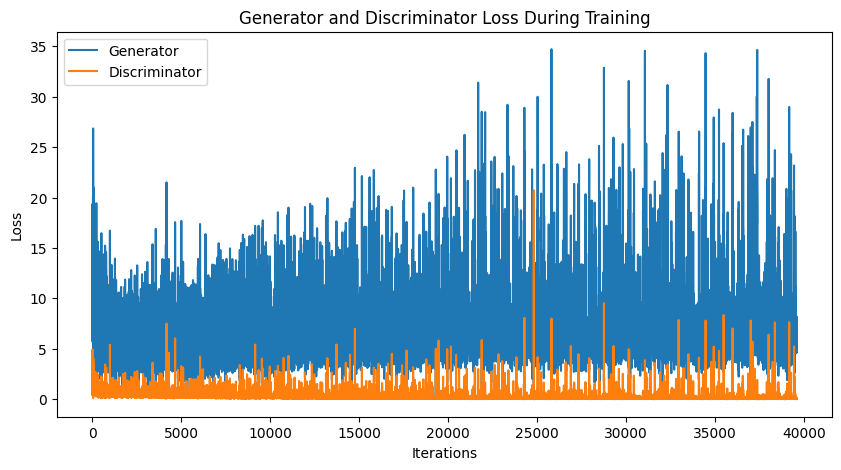


Visualizing with the generator model currently in memory.
Searching for 16 real 'long hair' images from the dataset...
Generating 16 fake 'long hair' images...


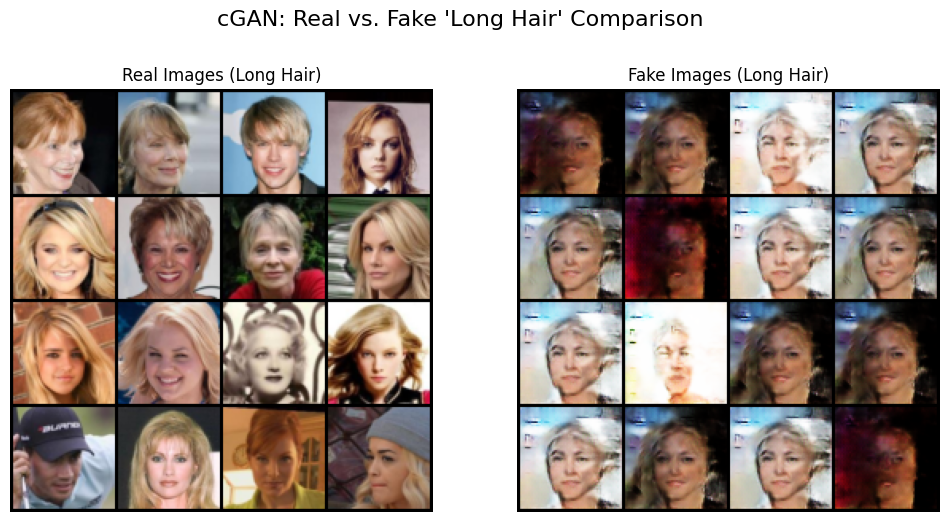

In [ ]:
if 'G_losses' in locals() and 'D_losses' in locals():
    plt.figure(figsize=(10, 5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(G_losses, label="Generator")
    plt.plot(D_losses, label="Discriminator")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Loss history not found in the current session. Skipping loss plot.")

try:
    netG.eval()
    print("\nVisualizing with the generator model currently in memory.")
except NameError:
    print("\nGenerator 'netG' not found. Loading from file...")
    netG = ConditionalGenerator().to(device)
    netG.load_state_dict(torch.load('cgan_longhair_generator.pth'))
    netG.eval()

print("Searching for 16 real 'long hair' images from the dataset...")
real_long_hair_images = []
num_needed = 16
for images, labels in dataloader:
    long_hair_in_batch = images[labels == 1]
    real_long_hair_images.append(long_hair_in_batch)
    
    if sum([len(b) for b in real_long_hair_images]) >= num_needed:
        break
real_long_hair_tensor = torch.cat(real_long_hair_images)[:num_needed]

print("Generating 16 fake 'long hair' images...")
with torch.no_grad():
    noise = torch.randn(num_needed, LATENT_DIM, 1, 1, device=device)
    long_hair_labels = torch.full((num_needed,), 1, dtype=torch.long, device=device)
    fake_long_hair_images = netG(noise, long_hair_labels).detach().cpu()

plt.figure(figsize=(12, 6))
plt.suptitle("cGAN: Real vs. Fake 'Long Hair' Comparison", fontsize=16)

plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images (Long Hair)")
real_grid = vutils.make_grid(real_long_hair_tensor, nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(real_grid, (1, 2, 0)))

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images (Long Hair)")
fake_grid = vutils.make_grid(fake_long_hair_images, nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(fake_grid, (1, 2, 0)))

plt.show()

## Alternative Visualization (Top/Bottom Layout)

Loss history not found in the current session. Skipping loss plot.
Successfully loaded trained generator from 'cgan_longhair_generator.pth'
Searching for 8 real 'long hair' images...
Generating 8 fake 'long hair' images...
Plotting results...


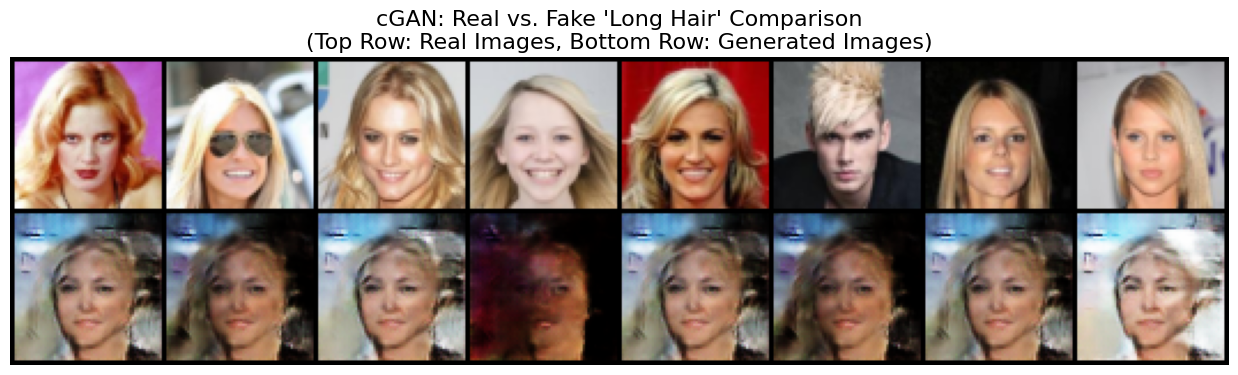

In [ ]:
if 'G_losses' in locals() and 'D_losses' in locals():
    plt.figure(figsize=(10, 5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(G_losses, label="Generator")
    plt.plot(D_losses, label="Discriminator")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Loss history not found in the current session. Skipping loss plot.")

GENERATOR_PATH = 'cgan_longhair_generator.pth'
netG = ConditionalGenerator().to(device)

try:
    netG.load_state_dict(torch.load(GENERATOR_PATH))
    print(f"Successfully loaded trained generator from '{GENERATOR_PATH}'")
except FileNotFoundError:
    print(f"Error: Model file not found at '{GENERATOR_PATH}'.")
    print("Please make sure the training was completed and the file was saved.")

netG.eval()
print("Searching for 8 real 'long hair' images...")
num_needed = 8
real_long_hair_images = []
for images, labels in dataloader:
    long_hair_in_batch = images[labels == 1]
    real_long_hair_images.append(long_hair_in_batch)
    if sum([len(b) for b in real_long_hair_images]) >= num_needed:
        break
real_long_hair_tensor = torch.cat(real_long_hair_images)[:num_needed]

print("Generating 8 fake 'long hair' images...")
with torch.no_grad():
    noise = torch.randn(num_needed, LATENT_DIM, 1, 1, device=device)
    long_hair_labels = torch.full((num_needed,), 1, dtype=torch.long, device=device)
    fake_long_hair_images = netG(noise, long_hair_labels).detach().cpu()

print("Plotting results...")
combined_images = torch.cat([real_long_hair_tensor.cpu(), fake_long_hair_images], dim=0)
plt.figure(figsize=(16, 4))
plt.axis("off")
plt.title("cGAN: Real vs. Fake 'Long Hair' Comparison\n(Top Row: Real Images, Bottom Row: Generated Images)", fontsize=16)
image_grid = vutils.make_grid(combined_images, nrow=8, padding=2, normalize=True)
plt.imshow(np.transpose(image_grid, (1, 2, 0)))

plt.show()

## Imports and Hyperparameters

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import glob
import random
import time
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
workers = 4
DATA_ROOT = '/media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/Datasets/cycleGAN'
IMAGE_SIZE = 128
CHANNELS = 3
BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 0.0002
ADAM_BETA_1 = 0.5
DECAY_START_EPOCH = 10
LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0

Using device: cuda:0


## Unpaired Image Dataset and Dataloader

In [ ]:
class ImageDataset(Dataset):
    """
    Custom Dataset for handling two unpaired image domains (A and B).
    """
    def __init__(self, root, transform=None, unaligned=True):
        self.transform = transform
        self.unaligned = unaligned

        self.files_A = sorted(glob.glob(os.path.join(root, 'trainA') + '/*.*'))
        self.files_B = sorted(glob.glob(os.path.join(root, 'trainB') + '/*.*'))
        
        print(f"Found {len(self.files_A)} images in trainA and {len(self.files_B)} images in trainB.")

    def __getitem__(self, index):
        image_A = Image.open(self.files_A[index % len(self.files_A)]).convert('RGB')
        if self.unaligned:
            index_B = random.randint(0, len(self.files_B) - 1)
        else:
            index_B = index % len(self.files_B)
        image_B = Image.open(self.files_B[index_B]).convert('RGB')

        if self.transform:
            item_A = self.transform(image_A)
            item_B = self.transform(image_B)

        return {'A': item_A, 'B': item_B}

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

transformations = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.12), Image.BICUBIC),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
cyclegan_dataset = ImageDataset(root=DATA_ROOT, transform=transformations)
dataloader = DataLoader(cyclegan_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=workers)

print(f"Dataset and DataLoader created successfully.")

Found 5000 images in trainA and 281 images in trainB.
Dataset and DataLoader created successfully.


## Model Architecture (Generator & Discriminator)

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm2d') != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features)
        )
    def forward(self, x):
        return x + self.block(x)

class GeneratorResNet(nn.Module):
    def __init__(self, input_shape, num_residual_blocks=9):
        super(GeneratorResNet, self).__init__()
        channels = input_shape[0]
        out_features = 64
        model = [nn.ReflectionPad2d(channels),
                 nn.Conv2d(channels, out_features, 7),
                 nn.InstanceNorm2d(out_features),
                 nn.ReLU(inplace=True)]
        in_features = out_features
        for _ in range(2):
            out_features *= 2
            model += [nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                      nn.InstanceNorm2d(out_features),
                      nn.ReLU(inplace=True)]
            in_features = out_features
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(out_features)]
        for _ in range(2):
            out_features //= 2
            model += [nn.Upsample(scale_factor=2),
                      nn.Conv2d(in_features, out_features, 3, stride=1, padding=1),
                      nn.InstanceNorm2d(out_features),
                      nn.ReLU(inplace=True)]
            in_features = out_features
        model += [nn.ReflectionPad2d(channels),
                  nn.Conv2d(out_features, channels, 7),
                  nn.Tanh()]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super(Discriminator, self).__init__()
        channels, height, width = input_shape
        self.output_shape = (1, height // 2**4, width // 2**4)
        def discriminator_block(in_filters, out_filters, normalize=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.model = nn.Sequential(
            *discriminator_block(channels, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )
    def forward(self, img):
        return self.model(img)

input_shape = (CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
G_AtoB = GeneratorResNet(input_shape).to(device)
G_BtoA = GeneratorResNet(input_shape).to(device)
D_A = Discriminator(input_shape).to(device)
D_B = Discriminator(input_shape).to(device)

G_AtoB.apply(weights_init)
G_BtoA.apply(weights_init)
D_A.apply(weights_init)
D_B.apply(weights_init)

print("CycleGAN models created successfully.")

CycleGAN models created successfully.


## Loss Functions, Optimizers, and Training Utilities

In [ ]:
criterion_GAN = torch.nn.MSELoss().to(device)
criterion_cycle = torch.nn.L1Loss().to(device)
criterion_identity = torch.nn.L1Loss().to(device)

import itertools
optimizer_G = torch.optim.Adam(itertools.chain(G_AtoB.parameters(), G_BtoA.parameters()), lr=LEARNING_RATE, betas=(ADAM_BETA_1, 0.999))
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=LEARNING_RATE, betas=(ADAM_BETA_1, 0.999))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=LEARNING_RATE, betas=(ADAM_BETA_1, 0.999))

class LambdaLR:
    def __init__(self, n_epochs, offset, decay_start_epoch):
        assert (n_epochs - decay_start_epoch) > 0, "Decay must start before training ends!"
        self.n_epochs = n_epochs
        self.offset = offset
        self.decay_start_epoch = decay_start_epoch
    def step(self, epoch):
        return 1.0 - max(0, epoch + self.offset - self.decay_start_epoch)/(self.n_epochs - self.decay_start_epoch)

lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=LambdaLR(EPOCHS, 0, DECAY_START_EPOCH).step)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=LambdaLR(EPOCHS, 0, DECAY_START_EPOCH).step)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=LambdaLR(EPOCHS, 0, DECAY_START_EPOCH).step)

class ReplayBuffer:
    def __init__(self, max_size=50):
        assert max_size > 0, "Empty buffer."
        self.max_size = max_size
        self.data = []
    def push_and_pop(self, data):
        to_return = []
        for element in data.data:
            element = torch.unsqueeze(element, 0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                to_return.append(element)
            else:
                if random.uniform(0, 1) > 0.5:
                    i = random.randint(0, self.max_size - 1)
                    to_return.append(self.data[i].clone())
                    self.data[i] = element
                else:
                    to_return.append(element)
        return torch.cat(to_return)

fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

print("Training utilities, optimizers, and schedulers initialized.")

Training utilities, optimizers, and schedulers initialized.


## Training Loop

In [ ]:
if __name__ == '__main__':
    output_dir_samples = 'cyclegan_samples'
    output_dir_models = 'cyclegan_models'
    os.makedirs(output_dir_samples, exist_ok=True)
    os.makedirs(output_dir_models, exist_ok=True)
    
    print("Starting CycleGAN Training...")
    
    for epoch in range(EPOCHS):
        start_time = time.time()
        for i, batch in enumerate(dataloader):
            real_A = batch['A'].to(device)
            real_B = batch['B'].to(device)
            target_real = torch.ones((real_A.size(0), *D_A.output_shape), requires_grad=False).to(device)
            target_fake = torch.zeros((real_A.size(0), *D_A.output_shape), requires_grad=False).to(device)
            G_AtoB.train()
            G_BtoA.train()
            optimizer_G.zero_grad()
            loss_id_A = criterion_identity(G_BtoA(real_A), real_A)
            loss_id_B = criterion_identity(G_AtoB(real_B), real_B)
            loss_identity = (loss_id_A + loss_id_B) / 2
            fake_B = G_AtoB(real_A)
            loss_GAN_AtoB = criterion_GAN(D_B(fake_B), target_real)
            fake_A = G_BtoA(real_B)
            loss_GAN_BtoA = criterion_GAN(D_A(fake_A), target_real)
            loss_GAN = (loss_GAN_AtoB + loss_GAN_BtoA) / 2
            reconstructed_A = G_BtoA(fake_B)
            loss_cycle_A = criterion_cycle(reconstructed_A, real_A)
            reconstructed_B = G_AtoB(fake_A)
            loss_cycle_B = criterion_cycle(reconstructed_B, real_B)
            loss_cycle = (loss_cycle_A + loss_cycle_B) / 2
            loss_G = loss_GAN + LAMBDA_CYCLE * loss_cycle + LAMBDA_IDENTITY * loss_identity
            loss_G.backward()
            optimizer_G.step()
            optimizer_D_A.zero_grad()
            loss_real = criterion_GAN(D_A(real_A), target_real)
            fake_A_ = fake_A_buffer.push_and_pop(fake_A)
            loss_fake = criterion_GAN(D_A(fake_A_.detach()), target_fake)
            loss_D_A = (loss_real + loss_fake) / 2
            loss_D_A.backward()
            optimizer_D_A.step()
            optimizer_D_B.zero_grad()
            loss_real = criterion_GAN(D_B(real_B), target_real)
            fake_B_ = fake_B_buffer.push_and_pop(fake_B)
            loss_fake = criterion_GAN(D_B(fake_B_.detach()), target_fake)
            loss_D_B = (loss_real + loss_fake) / 2
            loss_D_B.backward()
            optimizer_D_B.step()
        
        epoch_time = time.time() - start_time
        loss_D = (loss_D_A + loss_D_B) / 2
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss_D: {loss_D.item():.4f} | Loss_G: {loss_G.item():.4f} | Time: {epoch_time:.2f}s")

        lr_scheduler_G.step()
        lr_scheduler_D_A.step()
        lr_scheduler_D_B.step()
        sample_real_A = real_A[0].unsqueeze(0)
        sample_fake_B = G_AtoB(sample_real_A).detach()
        sample_real_B = real_B[0].unsqueeze(0)
        sample_fake_A = G_BtoA(sample_real_B).detach()
        image_grid = torch.cat((sample_real_A, sample_fake_B, sample_real_B, sample_fake_A), 0)
        vutils.save_image(image_grid, f"{output_dir_samples}/epoch_{epoch+1}.png", nrow=4, normalize=True)

        torch.save(G_AtoB.state_dict(), f"{output_dir_models}/G_AtoB.pth")
        torch.save(G_BtoA.state_dict(), f"{output_dir_models}/G_BtoA.pth")
        torch.save(D_A.state_dict(), f"{output_dir_models}/D_A.pth")
        torch.save(D_B.state_dict(), f"{output_dir_models}/D_B.pth")

## Visualization (Photo-to-Painting Translation)

Successfully loaded weights from 'cyclegan_models/G_AtoB.pth'
Fetching 16 real face photos from the dataset...
Translating photos to the painted domain...
Plotting results...


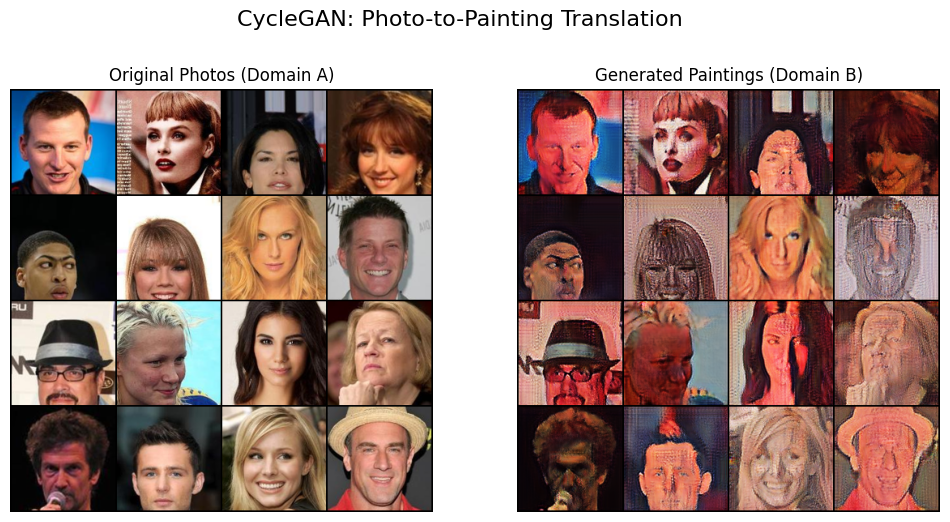

In [ ]:
GENERATOR_A_TO_B_PATH = 'cyclegan_models/G_AtoB.pth'
input_shape = (CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
G_AtoB = GeneratorResNet(input_shape).to(device)

try:
    G_AtoB.load_state_dict(torch.load(GENERATOR_A_TO_B_PATH))
    print(f"Successfully loaded weights from '{GENERATOR_A_TO_B_PATH}'")
except FileNotFoundError:
    print(f"Error: Model file not found at '{GENERATOR_A_TO_B_PATH}'.")
    print("Please make sure you have trained the model and the file exists.")

G_AtoB.eval()
print("Fetching 16 real face photos from the dataset...")
try:
    real_photos_list = []
    num_needed = 16
    for i, batch in enumerate(dataloader):
        real_photos_list.append(batch['A'])
        if sum([b.size(0) for b in real_photos_list]) >= num_needed:
            break

    real_photos = torch.cat(real_photos_list, 0)[:num_needed].to(device)
    
except NameError:
    print("Error: `dataloader` not found. Please run the data loading cell from your script first.")

print("Translating photos to the painted domain...")
with torch.no_grad():
    fake_paintings = G_AtoB(real_photos).detach().cpu()

print("Plotting results...")
plt.figure(figsize=(12, 6))
plt.suptitle("CycleGAN: Photo-to-Painting Translation", fontsize=16)
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Original Photos (Domain A)")
real_grid = vutils.make_grid(real_photos.cpu(), nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(real_grid, (1, 2, 0)))
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Generated Paintings (Domain B)")
fake_grid = vutils.make_grid(fake_paintings, nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(fake_grid, (1, 2, 0)))

plt.show()

## Alternative Visualization (Top/Bottom Layout)

Successfully loaded weights from 'cyclegan_models/G_AtoB.pth'
Fetching 8 real face photos from the dataset...
Translating photos to the painted domain...
Plotting results...


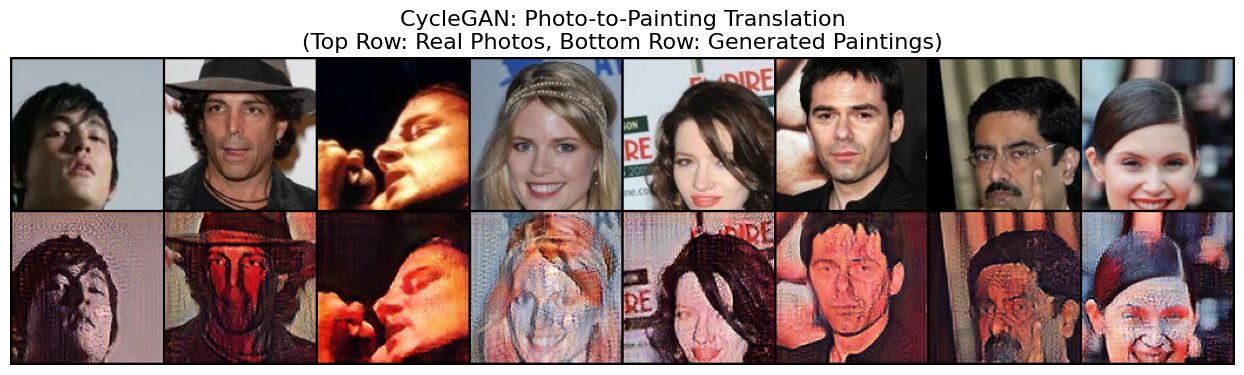

In [ ]:
GENERATOR_A_TO_B_PATH = 'cyclegan_models/G_AtoB.pth'
input_shape = (CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
G_AtoB = GeneratorResNet(input_shape).to(device)

try:
    G_AtoB.load_state_dict(torch.load(GENERATOR_A_TO_B_PATH))
    print(f"Successfully loaded weights from '{GENERATOR_A_TO_B_PATH}'")
except FileNotFoundError:
    print(f"Error: Model file not found at '{GENERATOR_A_TO_B_PATH}'.")

G_AtoB.eval()
print("Fetching 8 real face photos from the dataset...")
try:
    num_needed = 8
    real_photos_list = []
    for i, batch in enumerate(dataloader):
        real_photos_list.append(batch['A'])
        if sum([b.size(0) for b in real_photos_list]) >= num_needed:
            break
    
    real_photos = torch.cat(real_photos_list, 0)[:num_needed].to(device)
    
except NameError:
    print("Error: `dataloader` not found. Please run the data loading cell first.")

print("Translating photos to the painted domain...")
with torch.no_grad():
    fake_paintings = G_AtoB(real_photos).detach().cpu()

print("Plotting results...")
combined_images = torch.cat([real_photos.cpu(), fake_paintings], dim=0)
plt.figure(figsize=(16, 4))
plt.axis("off")
plt.title("CycleGAN: Photo-to-Painting Translation\n(Top Row: Real Photos, Bottom Row: Generated Paintings)", fontsize=16)
image_grid = vutils.make_grid(combined_images, nrow=8, padding=2, normalize=True)
plt.imshow(np.transpose(image_grid, (1, 2, 0)))

plt.show()